In [433]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime,timedelta
from pandas.plotting import register_matplotlib_converters
from statsmodels.tsa.stattools import acf,pacf
from statsmodels.tsa.arima.model import ARIMA
from time import time

In [434]:
register_matplotlib_converters()

<h2>Catfish Sales Data </h2>

In [435]:
def parser (s):
    return datetime.strptime(s,"%Y-%m-%d")

In [ ]:
catfish_sales=pd.read_csv("catfish",parse_dates=[0],index_col=0,date_format=parser)
catfish_sales.head()

,Total
Date,
1986-1-01,9034
1986-2-01,9596
1986-3-01,10558
1986-4-01,9002
1986-5-01,9239


In [437]:
catfish_sales.index=pd.to_datetime(catfish_sales.index)
catfish_sales.index[:5]

DatetimeIndex(['1986-01-01', '1986-02-01', '1986-03-01', '1986-04-01',
               '1986-05-01'],
              dtype='datetime64[ns]', name='Date', freq=None)

In [438]:
# infer the frequency of the data
catfish_sales = catfish_sales.asfreq(pd.infer_freq(catfish_sales.index))
catfish_sales.head()

,Total
Date,
1986-01-01,9034
1986-02-01,9596
1986-03-01,10558
1986-04-01,9002
1986-05-01,9239


In [439]:
start_date=datetime(2000,1,1)
end_date=datetime(2004,1,1)
lim_catfish_sales=catfish_sales[start_date:end_date]
lim_catfish_sales.head()

,Total
Date,
2000-01-01,25412
2000-02-01,25354
2000-03-01,29161
2000-04-01,24924
2000-05-01,24763


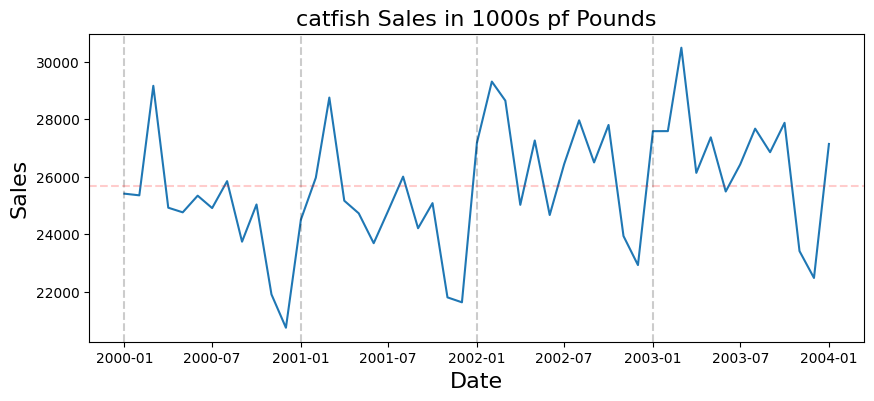

In [440]:
plt.figure(figsize=(10,4))
plt.title("catfish Sales in 1000s pf Pounds",fontsize=16)
plt.plot(lim_catfish_sales)
plt.ylabel("Sales",fontsize=16)
plt.xlabel("Date",fontsize=16)
for year in range(start_date.year,end_date.year):
    plt.axvline(pd.to_datetime(str(year)+"-01-01"),color="k",linestyle="--",alpha=.2)
plt.axhline(lim_catfish_sales["Total"].mean(),color="r",alpha=0.2,linestyle="--")
plt.show()


In [441]:
first_diff=lim_catfish_sales.diff()[1:]
first_diff[:5]

,Total
Date,
2000-02-01,-58.0
2000-03-01,3807.0
2000-04-01,-4237.0
2000-05-01,-161.0
2000-06-01,579.0


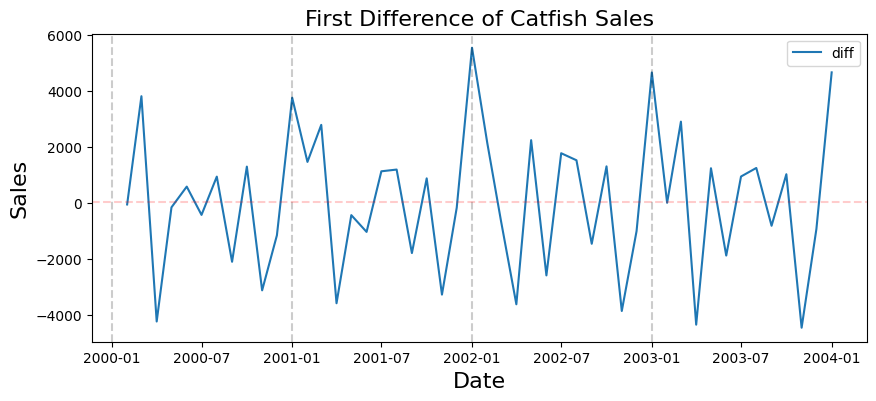

In [442]:
plt.figure(figsize=(10,4))
plt.plot(first_diff)
plt.title("First Difference of Catfish Sales",fontsize=16)
plt.ylabel("Sales",fontsize=16)
plt.xlabel("Date",fontsize=16)
plt.legend(["diff"])
for year in range(start_date.year,end_date.year):
   plt.axvline(pd.to_datetime(str(year)+'-01-01'), color='k', linestyle='--', alpha=0.2)
plt.axhline(first_diff["Total"].mean(), color='r', alpha=0.2, linestyle='--')
plt.show()

<h2> ACF </h2>

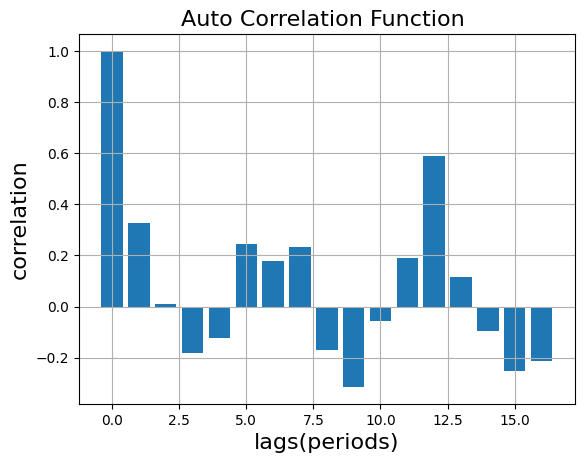

In [443]:
acf_vals=acf(lim_catfish_sales)
plt.bar(range(len(acf_vals)),acf_vals)
plt.ylabel("correlation",fontsize=16)
plt.xlabel("lags(periods)",fontsize=16)
plt.title("Auto Correlation Function ",fontsize=16)
plt.grid()
plt.show()

<h4> based on ACF,we should start with a MA(1) process</h4>

<h2> PACF</h2>

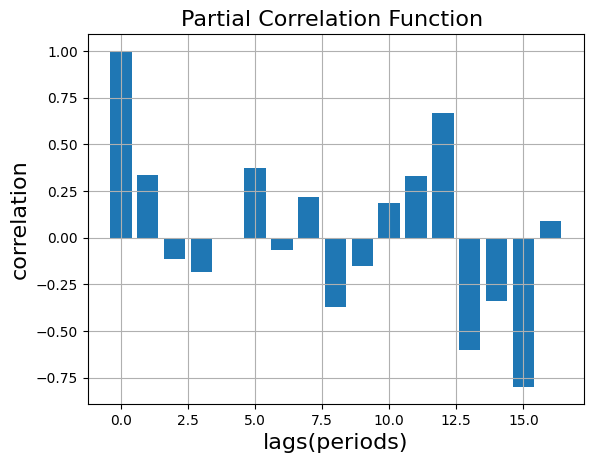

In [444]:
pacf_vals=pacf(lim_catfish_sales)
plt.bar(range(len(pacf_vals)),pacf_vals)
plt.xlabel("lags(periods)",fontsize=16)
plt.ylabel("correlation",fontsize=16)
plt.title("Partial Correlation Function ",fontsize=16)
plt.grid()
plt.show()

<h4> based in PACF we should start with a AR(5)</h4>

<h2> Get training and testing sets  </h2>

In [445]:
train_end=datetime(2002,1,1)
test_end=datetime(2003,1,1)

In [446]:
train_data=lim_catfish_sales[:train_end]
test_data=lim_catfish_sales[train_end+timedelta(days=1):test_end]

<h2>Fit the ARMA Model </h2>

In [ ]:
model=ARIMA(train_data,order=(4,0,1))

In [ ]:
start=time()
model_fit=model.fit()
end=time()
print("Model Fitting Time:",end-start)

Model Fitting Time: 0.05585074424743652


In [ ]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Total   No. Observations:                   25
Model:                 ARIMA(4, 0, 1)   Log Likelihood                -220.378
Date:                Tue, 18 Mar 2025   AIC                            454.757
Time:                        17:17:21   BIC                            463.289
Sample:                    01-01-2000   HQIC                           457.123
                         - 01-01-2002                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.483e+04    419.545     59.178      0.000     2.4e+04    2.57e+04
ar.L1         -0.4538      0.317     -1.430      0.153      -1.076       0.168
ar.L2          0.0350      0.322      0.109      0.9

<h4> So the ARMA(4,1) model is:</h4>

$$
\hat{y}_{t}=-0.4538  y_{t-1} + 0.0350 y_{t-2} -0.2574 y_{t-3}   -0.5286 y_{t-4} +  0.7739 \varepsilon_{t-1}        
$$

In [ ]:
pred_start_date=test_data.index[0]
pred_end_date=test_data.index[-1]

In [ ]:
predictions=model_fit.predict(start=pred_start_date,end=pred_end_date)
residuals=test_data["Total"] - predictions

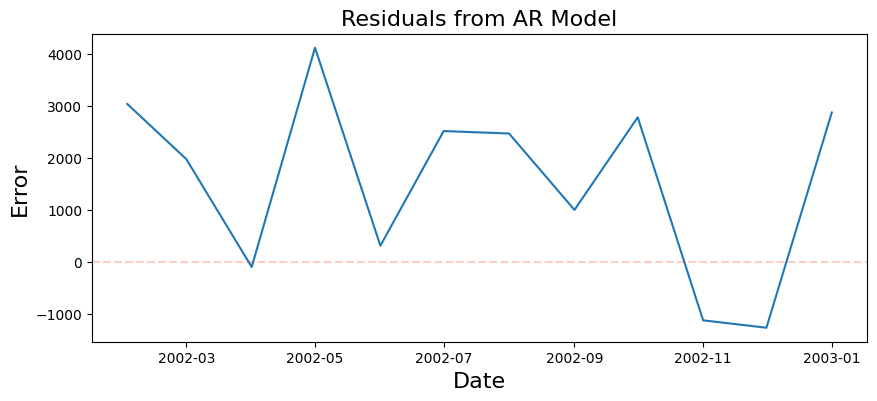

In [452]:
plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.title("Residuals from AR Model",fontsize=16)
plt.ylabel("Error",fontsize=16)
plt.xlabel("Date",fontsize=16)
plt.axhline(0,color="r",linestyle="--", alpha=.2)
plt.show()

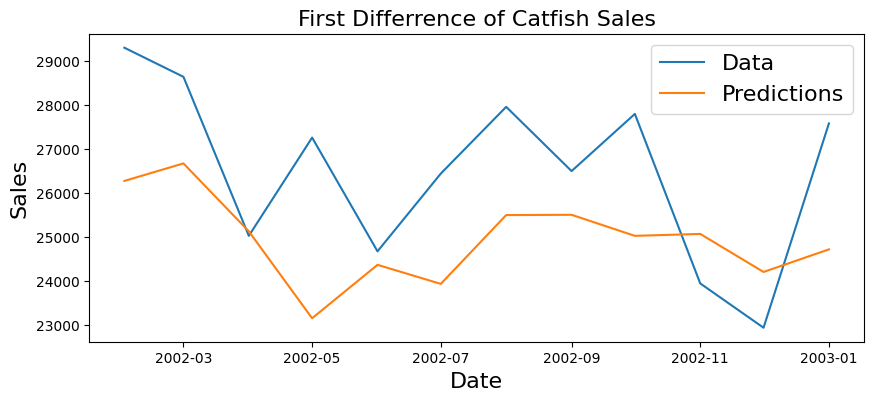

In [453]:
plt.figure(figsize=(10,4))
plt.plot(test_data)
plt.plot(predictions)
plt.legend(["Data","Predictions"],fontsize=16)
plt.title("First Differrence of Catfish Sales",fontsize=16)
plt.ylabel("Sales",fontsize=16)
plt.xlabel("Date",fontsize=16)
plt.show()

In [454]:
print("Root Mean Sqaured Error:",np.sqrt(np.mean(residuals**2)))

Root Mean Sqaured Error: 2279.4735684004695
